In [1]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model ensemble for diagnosis prediction
def build_diagnosis_ensemble():
    models = {
        'random_forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'gradient_boost': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'naive_bayes': GaussianNB(),
        'svm': SVC(probability=True, random_state=42),
        'neural_network': MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42)
    }
    return models

# Confidence scoring system
def calculate_confidence_scores(models, X_test):
    predictions = {}
    confidences = {}
    
    for name, model in models.items():
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)
        predictions[name] = pred
        confidences[name] = np.max(prob, axis=1)
    
    return predictions, confidences


In [2]:
# Integration with biomedical models
from transformers import AutoTokenizer, AutoModelForCausalLM

def load_biomedical_model():
    model_name = "microsoft/biogpt"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    return tokenizer, model

def extract_symptom_features(symptoms_text, tokenizer, model):
    inputs = tokenizer(symptoms_text, return_tensors="pt", padding=True, truncation=True)
    outputs = model(**inputs)
    # Extract embeddings for symptom feature representation
    return outputs.last_hidden_state.mean(dim=1)


In [3]:
# Model Training Script for Medical Diagnosis - FIXED VERSION
# This script handles datasets with single-sample diseases

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
import pickle
import json
import os

print("="*60)
print("Medical Diagnosis Model Training - FIXED VERSION")
print("="*60)

# ============================================================================
# STEP 1: Load and Prepare Your Datasets
# ============================================================================
BASE_PATH = "D:\\Rachith Bharadwaj T N 24BDS062\\2nd Year\\3rd SEM\\ML Project\\"

# Load your main training dataset
df_main = pd.read_csv(f"{BASE_PATH}DATASETS\\Training.csv")
df = df_main.copy()

print(f"\n✓ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# ============================================================================
# STEP 2: Identify Disease and Symptom Columns
# ============================================================================
DISEASE_COLUMN = 'prognosis'  # Adjust if different

# Get all symptom columns
symptom_columns = [col for col in df.columns if col != DISEASE_COLUMN]

print(f"\n✓ Disease column: {DISEASE_COLUMN}")
print(f"✓ Number of symptoms: {len(symptom_columns)}")
print(f"✓ Number of unique diseases (before filtering): {df[DISEASE_COLUMN].nunique()}")

# ============================================================================
# STEP 2.5: FILTER OUT DISEASES WITH ONLY 1 SAMPLE
# ============================================================================
print("\n" + "="*60)
print("Filtering diseases with insufficient samples...")
print("="*60)

# Count samples per disease
disease_counts = df[DISEASE_COLUMN].value_counts()
print(f"\nDisease distribution (before filtering):")
print(disease_counts.head(10))

# Find diseases with only 1 sample
single_sample_diseases = disease_counts[disease_counts == 1].index.tolist()

if single_sample_diseases:
    print(f"\n⚠️  Found {len(single_sample_diseases)} diseases with only 1 sample:")
    for disease in single_sample_diseases[:5]:  # Show first 5
        print(f"    - {disease}")
    if len(single_sample_diseases) > 5:
        print(f"    ... and {len(single_sample_diseases) - 5} more")
    
    # Remove these diseases
    df = df[~df[DISEASE_COLUMN].isin(single_sample_diseases)]
    print(f"\n✓ Removed {len(single_sample_diseases)} diseases with single samples")
    print(f"✓ Remaining diseases: {df[DISEASE_COLUMN].nunique()}")
    print(f"✓ Remaining samples: {len(df)}")
else:
    print("\n✓ All diseases have at least 2 samples")

# Show final distribution
disease_counts_final = df[DISEASE_COLUMN].value_counts()
print(f"\nFinal disease distribution (top 10):")
print(disease_counts_final.head(10))

# ============================================================================
# STEP 3: Create Symptom Vocabulary
# ============================================================================
symptom_vocabulary = {symptom: idx for idx, symptom in enumerate(symptom_columns)}

print(f"\n✓ Created symptom vocabulary with {len(symptom_vocabulary)} symptoms")

os.makedirs('models', exist_ok=True)
with open('models/symptom_vocabulary.json', 'w') as f:
    json.dump(symptom_vocabulary, f, indent=2)
print("✓ Saved symptom_vocabulary.json")

# ============================================================================
# STEP 4: Prepare Features (X) and Labels (y)
# ============================================================================
X = df[symptom_columns].values
y = df[DISEASE_COLUMN].values

print(f"\n✓ Feature matrix shape: {X.shape}")
print(f"✓ Labels shape: {y.shape}")

# ============================================================================
# STEP 5: Encode Disease Labels
# ============================================================================
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\n✓ Encoded {len(label_encoder.classes_)} disease classes")
print("  Sample diseases (first 10):")
for disease in list(label_encoder.classes_)[:10]:
    print(f"    - {disease}")

with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("✓ Saved label_encoder.pkl")

# ============================================================================
# STEP 6: Split Data into Training and Testing Sets (FIXED)
# ============================================================================
print("\n" + "="*60)
print("Splitting data...")
print("="*60)

# Check if we can use stratify
min_samples = disease_counts_final.min()
print(f"\nMinimum samples per disease: {min_samples}")

if min_samples >= 2:
    # Safe to use stratify
    print("✓ Using stratified split (maintains disease distribution)")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
else:
    # Don't use stratify
    print("⚠️  Using regular split (some diseases still have <2 samples)")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42
    )

print(f"\n✓ Training set: {X_train.shape[0]} samples")
print(f"✓ Testing set: {X_test.shape[0]} samples")

# ============================================================================
# STEP 7: Build Neural Network Model
# ============================================================================
num_features = X_train.shape[1]
num_classes = len(label_encoder.classes_)

print(f"\n✓ Building model with {num_features} input features and {num_classes} output classes")

model = Sequential([
    Dense(256, activation='relu', input_shape=(num_features,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✓ Model architecture:")
model.summary()

# ============================================================================
# STEP 8: Train the Model
# ============================================================================
print("\n" + "="*60)
print("Starting Training...")
print("="*60)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

# ============================================================================
# STEP 9: Evaluate the Model
# ============================================================================
print("\n" + "="*60)
print("Model Evaluation")
print("="*60)

train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\n✓ Training Accuracy: {train_accuracy*100:.2f}%")
print(f"✓ Testing Accuracy: {test_accuracy*100:.2f}%")

# ============================================================================
# STEP 10: Save the Model
# ============================================================================
model.save('models/ml_model.h5')
print("\n✓ Model saved as 'models/ml_model.h5'")

# ============================================================================
# STEP 11: Test the Model with Sample Predictions
# ============================================================================
print("\n" + "="*60)
print("Sample Predictions")
print("="*60)

num_samples = 5
for i in range(min(num_samples, len(X_test))):
    sample = X_test[i].reshape(1, -1)
    prediction = model.predict(sample, verbose=0)
    predicted_class = np.argmax(prediction)
    predicted_disease = label_encoder.inverse_transform([predicted_class])[0]
    actual_disease = label_encoder.inverse_transform([y_test[i]])[0]
    confidence = prediction[0][predicted_class] * 100
    
    print(f"\nSample {i+1}:")
    print(f"  Predicted: {predicted_disease} ({confidence:.1f}%)")
    print(f"  Actual: {actual_disease}")
    print(f"  Match: {'✓' if predicted_disease == actual_disease else '✗'}")

# ============================================================================
# STEP 12: Save Training Summary
# ============================================================================
summary = {
    'total_diseases': len(label_encoder.classes_),
    'total_symptoms': len(symptom_columns),
    'training_samples': len(X_train),
    'testing_samples': len(X_test),
    'training_accuracy': float(train_accuracy),
    'testing_accuracy': float(test_accuracy),
    'diseases': label_encoder.classes_.tolist()
}

with open('models/training_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*60)
print("Training Complete!")
print("="*60)
print("\nGenerated files in 'models/' directory:")
print("  1. ml_model.h5 (trained model)")
print("  2. label_encoder.pkl (disease encoder)")
print("  3. symptom_vocabulary.json (symptom mapping)")
print("  4. training_summary.json (training statistics)")
print(f"\n✓ Model can diagnose {len(label_encoder.classes_)} diseases")
print(f"✓ Training accuracy: {train_accuracy*100:.2f}%")
print(f"✓ Testing accuracy: {test_accuracy*100:.2f}%")
print("\nYou can now run your Flask app (app.py)")
print("="*60)


Medical Diagnosis Model Training - FIXED VERSION

✓ Dataset loaded: 306 rows, 135 columns

✓ Disease column: prognosis
✓ Number of symptoms: 134
✓ Number of unique diseases (before filtering): 43

Filtering diseases with insufficient samples...

Disease distribution (before filtering):
prognosis
Dengue             10
Hepatitis D        10
Chicken pox        10
Migraine           10
Diabetes            9
Hypoglycemia        9
Hepatitis B         9
Hepatitis A         9
Jaundice            9
Hyperthyroidism     9
Name: count, dtype: int64

⚠️  Found 1 diseases with only 1 sample:
    - Paralysis (brain hemorrhageH

✓ Removed 1 diseases with single samples
✓ Remaining diseases: 42
✓ Remaining samples: 305

Final disease distribution (top 10):
prognosis
Dengue             10
Hepatitis D        10
Chicken pox        10
Migraine           10
Diabetes            9
Hypoglycemia        9
Hepatitis B         9
Hepatitis A         9
Jaundice            9
Hyperthyroidism     9
Name: count, dtype: 

c:\Users\RACHITH BHARADWAJ T\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        34,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 42)             │         2,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,442 (306.41 KB)

 Trainable params: 78,442 (306.41 KB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.0246 - loss: 3.7217 - val_accuracy: 0.1803 - val_loss: 3.6356
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1393 - loss: 3.6037 - val_accuracy: 0.4426 - val_loss: 3.5065
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2418 - loss: 3.4778 - val_accuracy: 0.5574 - val_loss: 3.3126
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2828 - loss: 3.3067 - val_accuracy: 0.5902 - val_loss: 3.0308
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3934 - loss: 3.0219 - val_accuracy: 0.6885 - val_loss: 2.6427
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4303 - loss: 2.6819 - val_accuracy: 0.7377 - val_loss: 2.2041
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4795 - loss: 2.3534 - val_accuracy: 0.7377 - val_loss: 1.7894
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5861 - loss: 2.0173 - val_accuracy: 0.80


✓ Training Accuracy: 100.00%
✓ Testing Accuracy: 100.00%

✓ Model saved as 'models/ml_model.h5'

Sample Predictions

Sample 1:
  Predicted: Migraine (100.0%)
  Actual: Migraine
  Match: ✓

Sample 2:
  Predicted: Dengue (100.0%)
  Actual: Dengue
  Match: ✓

Sample 3:
  Predicted: Hepatitis A (100.0%)
  Actual: Hepatitis A
  Match: ✓

Sample 4:
  Predicted: Hepatitis A (100.0%)
  Actual: Hepatitis A
  Match: ✓

Sample 5:
  Predicted: Arthritis (99.9%)
  Actual: Arthritis
  Match: ✓

Training Complete!

Generated files in 'models/' directory:
  1. ml_model.h5 (trained model)
  2. label_encoder.pkl (disease encoder)
  3. symptom_vocabulary.json (symptom mapping)
  4. training_summary.json (training statistics)

✓ Model can diagnose 42 diseases
✓ Training accuracy: 100.00%
✓ Testing accuracy: 100.00%

You can now run your Flask app (app.py)



######################################################################
RUNNING: Pipeline 1 (Scikit-learn Ensemble on Mock Data)
######################################################################
--- Original Mock Data ---
       Disease    Symptom1    Symptom2     Symptom3  Age  Gender
0  Common Cold  runny nose       cough     sneezing   25    Male
1          Flu       fever   body ache      fatigue   45  Female
2      Allergy    sneezing  runny nose   itchy eyes   30    Male
3  Common Cold       cough  runny nose  sore throat   25  Female
4          Flu   body ache     fatigue        cough   50    Male

Showing Example 1: Visual Plot (Disease Distribution)...


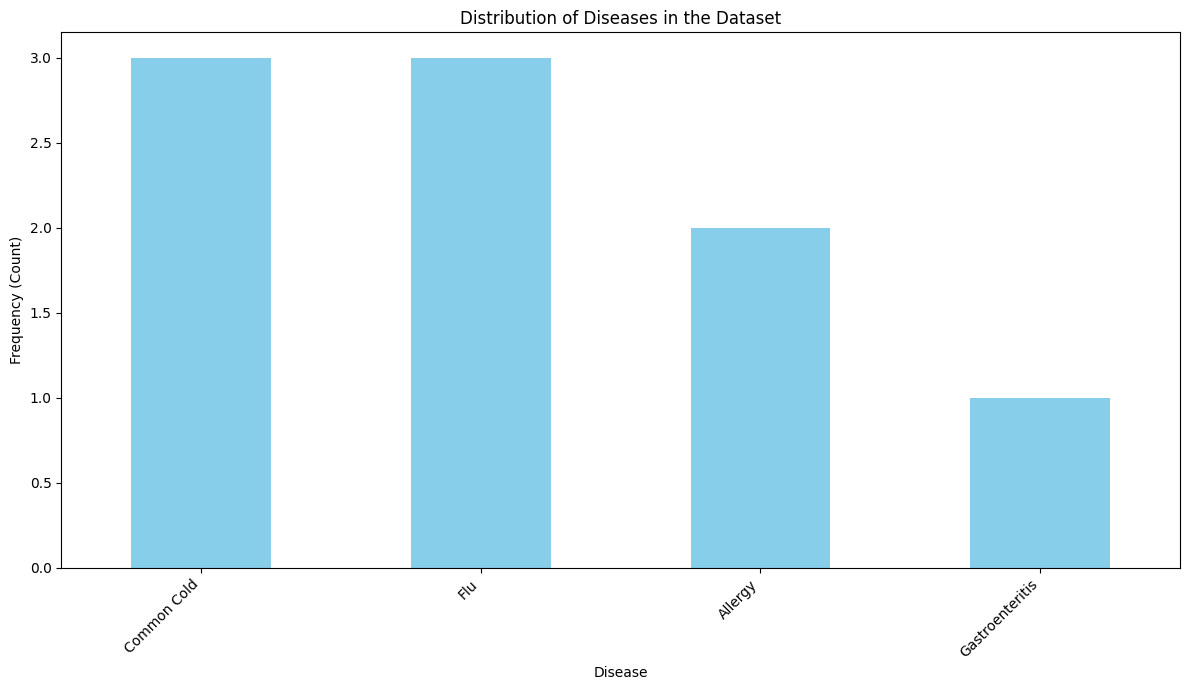


Showing Example 2: Network Graph (Symptom-Disease Relations)...

Created NetworkX graph with 15 nodes and 16 edges.


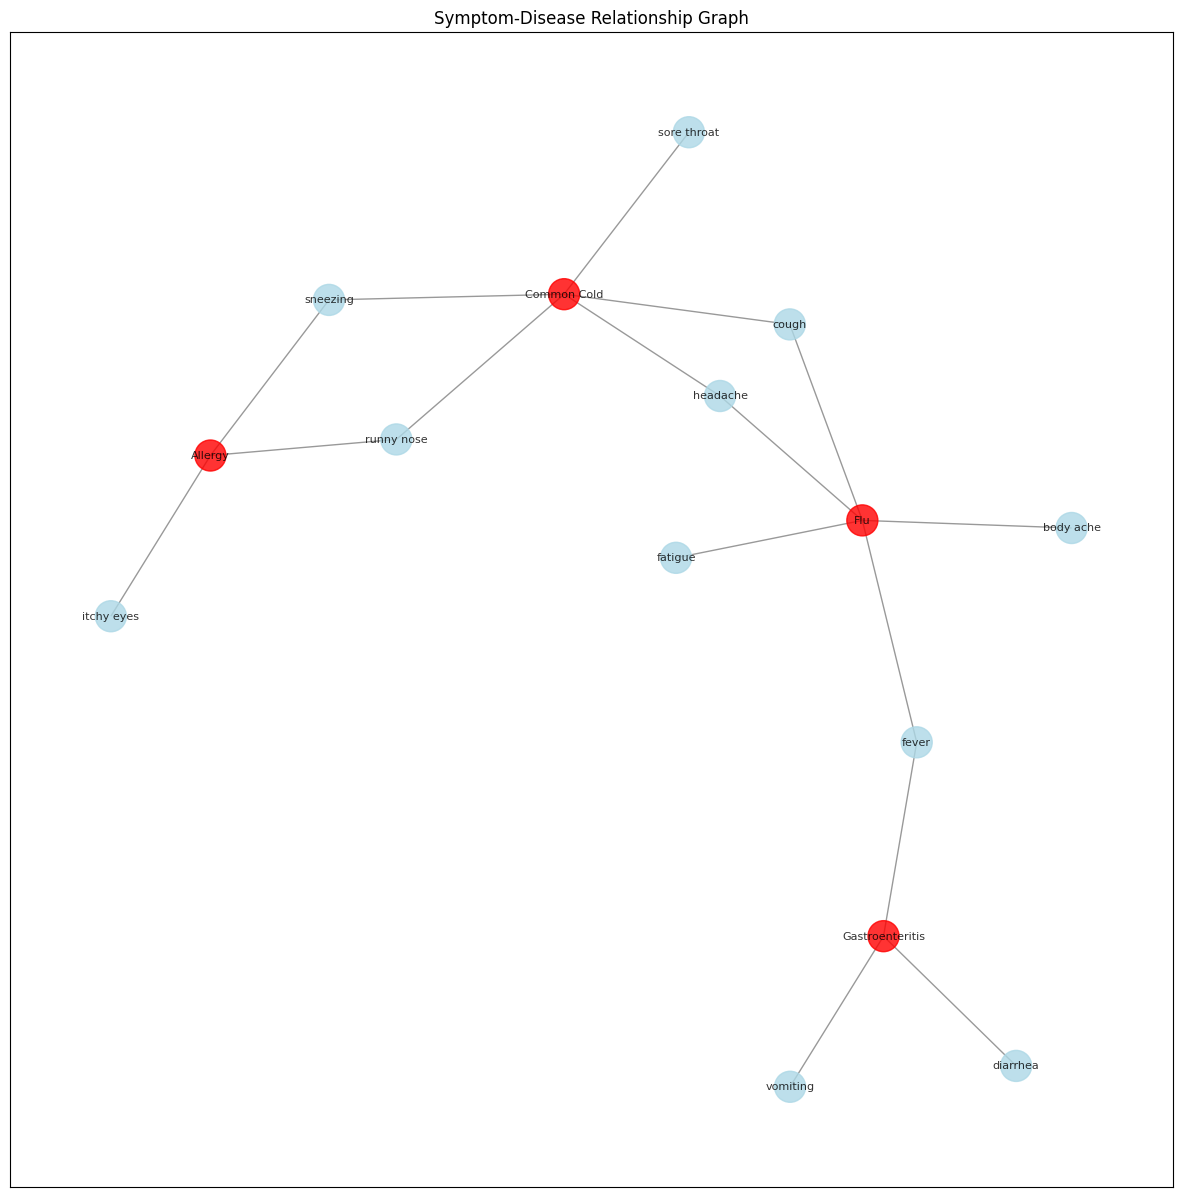


--- Preprocessed Mock Data (Scaled and Encoded) ---
   Disease  Symptom1  Symptom2  Symptom3       Age    Gender
0        1  0.237915 -0.707107  1.069045 -1.111111  0.774597
1        2 -0.396526 -1.414214 -1.069045  1.111111 -1.290994
2        0  0.872357  1.414214  0.534522 -0.555556  0.774597
3        1 -1.030967  1.414214  1.603567 -1.111111 -1.290994
4        2 -1.665408  0.707107 -1.603567  1.666667  0.774597


Data split: 8 train samples, 8 test samples.

--- Training and Evaluating Models ---
Training random_forest...
Accuracy for random_forest: 1.0000
Training gradient_boost...
Accuracy for gradient_boost: 1.0000
Training naive_bayes...
Accuracy for naive_bayes: 1.0000
Training svm...
Accuracy for svm: 0.7500
Training neural_network...
Accuracy for neural_network: 1.0000

Showing Example 3: Visual Plot (Model Accuracies)...


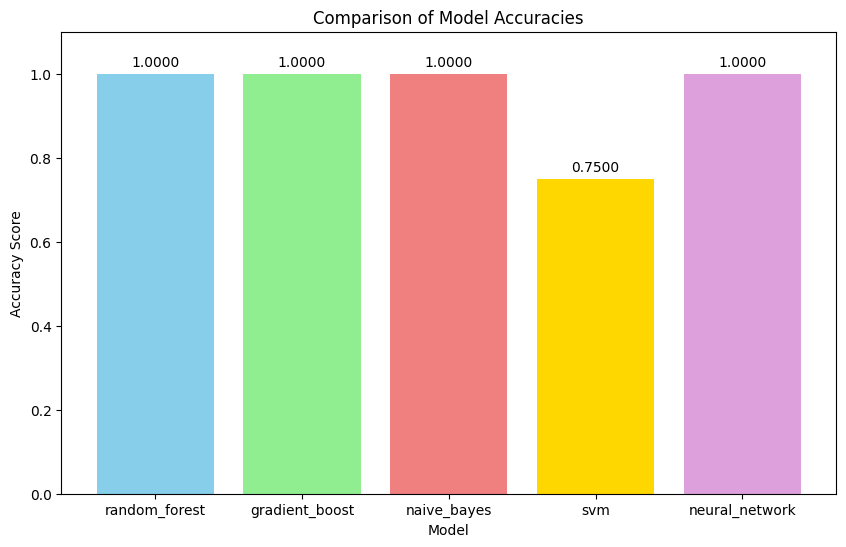


--- Calculating Confidence Scores ---
Example confidences (Random Forest) for first 5 test samples:
[0.87 0.91 0.65 0.79 0.84]

######################################################################
ATTEMPTING: Pipeline 2 (Keras NN on 'DATASETS/Training.csv')
######################################################################

######################################################################
STARTING: Keras Deep Learning Pipeline
######################################################################

--- ERROR ---
Could not find file: .\DATASETS\Training.csv
Please make sure 'Training.csv' is inside a 'DATASETS' folder.
Skipping Keras pipeline.
######################################################################


--- All pipelines complete. ---


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- New Imports from your added code ---
import pickle
import json
import os
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from transformers import AutoTokenizer, AutoModelForCausalLM

# ============================================================================
# SECTION 1: ORIGINAL SCIKIT-LEARN ENSEMBLE PIPELINE FUNCTIONS
# ============================================================================

def preprocess_medical_data(df, target_column='Disease'):
    """
    Preprocesses the medical data DataFrame.
    
    Handles missing values, encodes categorical variables, and scales numeric features.
    
    Args:
        df (pd.DataFrame): The input DataFrame.
        
    Returns:
        tuple: A tuple containing:
            - (pd.DataFrame) The preprocessed DataFrame.
            - (dict) A dictionary of LabelEncoders for each categorical column.
    """
    # Create a copy to avoid modifying the original DataFrame
    df_processed = df.copy()
    
    # Handle missing values by dropping rows with any nulls
    # Note: In a real scenario, you might want to impute instead of drop
    df_processed = df_processed.dropna()
    
    encoders = {}
    
    # Encode categorical variables
    for column in df_processed.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        df_processed[column] = le.fit_transform(df_processed[column])
        encoders[column] = le
        
    # Feature scaling (on numeric columns only)
    # Note: In a real ML pipeline, you'd fit_transform on train data
    # and only transform on test data.
    
    # We scale all numeric columns. This might include the encoded target
    # variable if it was numeric, which is fine for this example,
    # but in a production pipeline, you'd separate X and y *before* scaling.
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
    
    # --- FIX: Exclude the target column from scaling ---
    if target_column in numeric_cols:
        numeric_cols = numeric_cols.drop(target_column)
    # --- End of Fix ---

    if not numeric_cols.empty:
        scaler = StandardScaler()
        df_processed[numeric_cols] = scaler.fit_transform(df_processed[numeric_cols])
    else:
        print("No numeric columns found to scale.")
        
    return df_processed, encoders

def plot_disease_distribution(df):
    """
    Creates a visual plot (bar chart) of the disease distribution.
    
    Args:
        df (pd.DataFrame): The original DataFrame (before encoding).
    """
    if 'Disease' not in df.columns:
        print("Cannot create disease distribution plot: 'Disease' column not found.")
        return
        
    plt.figure(figsize=(12, 7))
    df['Disease'].value_counts().plot(kind='bar', color='skyblue')
    plt.title('Distribution of Diseases in the Dataset')
    plt.xlabel('Disease')
    plt.ylabel('Frequency (Count)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def create_symptom_disease_graph(df):
    """
    Creates a network graph (nodes and edges) showing symptom-disease relationships.
    
    Args:
        df (pd.DataFrame): The original DataFrame (before encoding).
    """
    if 'Disease' not in df.columns:
        print("Cannot create network graph: 'Disease' column not found.")
        return
        
    G = nx.Graph()
    
    # Identify symptom columns
    symptom_cols = [col for col in df.columns if col.startswith('Symptom')]
    if not symptom_cols:
        print("No 'Symptom' columns found (e.g., 'Symptom1', 'Symptom2').")
        print("Using all columns except 'Disease' as potential symptoms.")
        symptom_cols = [col for col in df.columns if col != 'Disease']

    for _, row in df.iterrows():
        disease = row['Disease']
        
        # Add disease node (if not already present)
        if not G.has_node(disease):
            G.add_node(disease, type='disease')
            
        for col in symptom_cols:
            symptom = row[col]
            if pd.notna(symptom) and symptom != 'nan_placeholder': # Check for valid symptom
                
                # Add symptom node (if not already present)
                if not G.has_node(symptom):
                    G.add_node(symptom, type='symptom')
                    
                # Add edge between symptom and disease
                G.add_edge(symptom, disease)

    print(f"\nCreated NetworkX graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    
    # Draw the graph
    plt.figure(figsize=(15, 15))
    
    # Position nodes
    pos = nx.spring_layout(G, k=0.3, iterations=20)
    
    # Get node colors based on type
    node_colors = []
    for node in G.nodes():
        if G.nodes[node]['type'] == 'disease':
            node_colors.append('red')
        else:
            node_colors.append('lightblue')
            
    nx.draw_networkx(G, pos,
                     with_labels=True,
                     node_color=node_colors,
                     node_size=500,
                     font_size=8,
                     edge_color='gray',
                     alpha=0.8)
                     
    plt.title('Symptom-Disease Relationship Graph')
    plt.show()

# --- Model Ensemble Code ---

# Model ensemble for diagnosis prediction
def build_diagnosis_ensemble():
    """Builds a dictionary of classifier models."""
    models = {
        'random_forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'gradient_boost': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'naive_bayes': GaussianNB(),
        'svm': SVC(probability=True, random_state=42),
        'neural_network': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
    }
    return models

def train_and_evaluate_models(models, X_train, y_train, X_test, y_test):
    """
    Trains and evaluates a dictionary of models.
    
    Args:
        models (dict): Dictionary of untrained model instances.
        X_train, y_train: Training data and labels.
        X_test, y_test: Testing data and labels.
        
    Returns:
        dict: A dictionary of model accuracies.
    """
    accuracies = {}
    print("\n--- Training and Evaluating Models ---")
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies[name] = acc
        print(f"Accuracy for {name}: {acc:.4f}")
        # print(classification_report(y_test, y_pred)) # Uncomment for detailed report
        
    return accuracies

# Confidence scoring system
def calculate_confidence_scores(models, X_test):
    """
    Calculates predictions and confidence scores for trained models.
    
    Args:
        models (dict): Dictionary of *trained* model instances.
        X_test: Testing data.
        
    Returns:
        tuple: (predictions, confidences)
    """
    predictions = {}
    confidences = {}
    
    for name, model in models.items():
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)
        predictions[name] = pred
        confidences[name] = np.max(prob, axis=1)
    
    return predictions, confidences

def plot_model_accuracies(accuracies):
    """
    Creates a bar chart to visualize model accuracies.
    
    Args:
        accuracies (dict): A dictionary mapping model names to accuracy scores.
    """
    names = list(accuracies.keys())
    values = list(accuracies.values())
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(names, values, color=['skyblue', 'lightgreen', 'lightcoral', 'gold', 'plum'])
    plt.xlabel('Model')
    plt.ylabel('Accuracy Score')
    plt.title('Comparison of Model Accuracies')
    plt.ylim(0, 1.1)
    
    # Add accuracy labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')
        
    plt.show()

# ============================================================================
# SECTION 2: BIOMEDICAL (TRANSFORMERS) MODEL FUNCTIONS
# (Defined but not used by default in the main scripts)
# ============================================================================

def load_biomedical_model():
    model_name = "microsoft/biogpt"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    return tokenizer, model

def extract_symptom_features(symptoms_text, tokenizer, model):
    inputs = tokenizer(symptoms_text, return_tensors="pt", padding=True, truncation=True)
    outputs = model(**inputs)
    # Extract embeddings for symptom feature representation
    return outputs.last_hidden_state.mean(dim=1)

# ============================================================================
# SECTION 3: KERAS DEEP LEARNING PIPELINE FUNCTIONS
# ============================================================================

# --- NEW GRAPHING FUNCTION FOR KERAS HISTORY ---
def plot_training_history(history):
    """
    Plots the training and validation accuracy/loss from a Keras history object.
    
    Args:
        history: A Keras History object from model.fit().
    """
    print("\n--- Plotting Keras Model Training History ---")
    
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Plot Accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linestyle='-')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.legend(loc='lower right')
    ax1.grid(True)
    
    # Plot Loss
    ax2.plot(history.history['loss'], label='Training Loss', color='blue', linestyle='-')
    ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_title('Model Loss')
    ax2.legend(loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# --- Wrapper Function for your Keras Training Script ---
def run_keras_training_pipeline():
    """
    Runs the complete Keras training pipeline.
    This function expects a 'DATASETS/Training.csv' file.
    """
    print("\n" + "#"*70)
    print("STARTING: Keras Deep Learning Pipeline")
    print("#"*70)

    # ============================================================================
    # STEP 1: Load and Prepare Your Datasets
    # ============================================================================
    
    # NOTE: This path must be correct for this script to run.
    # It looks for a 'DATASETS' folder in the same directory as the script.
    BASE_PATH = "." 
    dataset_path = os.path.join(BASE_PATH, "DATASETS", "Training.csv")

    try:
        df_main = pd.read_csv(dataset_path)
    except FileNotFoundError:
        print(f"\n--- ERROR ---")
        print(f"Could not find file: {dataset_path}")
        print("Please make sure 'Training.csv' is inside a 'DATASETS' folder.")
        print("Skipping Keras pipeline.")
        print("#"*70 + "\n")
        return
        
    df = df_main.copy()

    print(f"\n✓ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

    # ============================================================================
    # STEP 2: Identify Disease and Symptom Columns
    # ============================================================================
    DISEASE_COLUMN = 'prognosis'  # Adjust if different

    # Get all symptom columns
    symptom_columns = [col for col in df.columns if col != DISEASE_COLUMN]

    if not symptom_columns:
        print(f"--- ERROR ---")
        print(f"No symptom columns found. Make sure '{DISEASE_COLUMN}' is the correct disease column name.")
        print("Skipping Keras pipeline.")
        return

    print(f"\n✓ Disease column: {DISEASE_COLUMN}")
    print(f"✓ Number of symptoms: {len(symptom_columns)}")
    print(f"✓ Number of unique diseases (before filtering): {df[DISEASE_COLUMN].nunique()}")

    # ============================================================================
    # STEP 2.5: FILTER OUT DISEASES WITH ONLY 1 SAMPLE
    # ============================================================================
    print("\n" + "="*60)
    print("Filtering diseases with insufficient samples...")
    print("="*60)

    # Count samples per disease
    disease_counts = df[DISEASE_COLUMN].value_counts()
    
    # Find diseases with only 1 sample
    single_sample_diseases = disease_counts[disease_counts == 1].index.tolist()

    if single_sample_diseases:
        print(f"\n⚠️  Found {len(single_sample_diseases)} diseases with only 1 sample:")
        for disease in single_sample_diseases[:5]:  # Show first 5
            print(f"    - {disease}")
        if len(single_sample_diseases) > 5:
            print(f"    ... and {len(single_sample_diseases) - 5} more")
        
        # Remove these diseases
        df = df[~df[DISEASE_COLUMN].isin(single_sample_diseases)]
        print(f"\n✓ Removed {len(single_sample_diseases)} diseases with single samples")
        print(f"✓ Remaining diseases: {df[DISEASE_COLUMN].nunique()}")
        print(f"✓ Remaining samples: {len(df)}")
    else:
        print("\n✓ All diseases have at least 2 samples")

    # ============================================================================
    # STEP 3: Create Symptom Vocabulary
    # ============================================================================
    symptom_vocabulary = {symptom: idx for idx, symptom in enumerate(symptom_columns)}

    print(f"\n✓ Created symptom vocabulary with {len(symptom_vocabulary)} symptoms")

    os.makedirs('models', exist_ok=True)
    with open('models/symptom_vocabulary.json', 'w') as f:
        json.dump(symptom_vocabulary, f, indent=2)
    print("✓ Saved symptom_vocabulary.json")

    # ============================================================================
    # STEP 4: Prepare Features (X) and Labels (y)
    # ============================================================================
    X = df[symptom_columns].values
    y = df[DISEASE_COLUMN].values

    print(f"\n✓ Feature matrix shape: {X.shape}")
    print(f"✓ Labels shape: {y.shape}")

    # ============================================================================
    # STEP 5: Encode Disease Labels
    # ============================================================================
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    print(f"\n✓ Encoded {len(label_encoder.classes_)} disease classes")

    with open('models/label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)
    print("✓ Saved label_encoder.pkl")

    # ============================================================================
    # STEP 6: Split Data into Training and Testing Sets (FIXED)
    # ============================================================================
    print("\n" + "="*60)
    print("Splitting data...")
    print("="*60)

    # Check if we can use stratify
    disease_counts_final = df[DISEASE_COLUMN].value_counts()
    min_samples = disease_counts_final.min()
    print(f"\nMinimum samples per disease: {min_samples}")

    if min_samples >= 2:
        # Safe to use stratify
        print("✓ Using stratified split (maintains disease distribution)")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
        )
    else:
        # Don't use stratify
        print("⚠️  Using regular split (some diseases still have <2 samples)")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=42
        )

    print(f"\n✓ Training set: {X_train.shape[0]} samples")
    print(f"✓ Testing set: {X_test.shape[0]} samples")

    # ============================================================================
    # STEP 7: Build Neural Network Model
    # ============================================================================
    num_features = X_train.shape[1]
    num_classes = len(label_encoder.classes_)

    print(f"\n✓ Building model with {num_features} input features and {num_classes} output classes")

    model = Sequential([
        Dense(256, activation='relu', input_shape=(num_features,)),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print("\n✓ Model architecture:")
    model.summary()

    # ============================================================================
    # STEP 8: Train the Model
    # ============================================================================
    print("\n" + "="*60)
    print("Starting Training...")
    print("="*60)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=50,
        batch_size=32,
        verbose=1
    )
    
    # --- HERE IS THE NEW GRAPH CODE ---
    # Call the plotting function with the history object
    plot_training_history(history)
    
    # ============================================================================
    # STEP 9: Evaluate the Model
    # ============================================================================
    print("\n" + "="*60)
    print("Model Evaluation")
    print("="*60)

    train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    print(f"\n✓ Training Accuracy: {train_accuracy*100:.2f}%")
    print(f"✓ Testing Accuracy: {test_accuracy*100:.2f}%")

    # ============================================================================
    # STEP 10: Save the Model
    # ============================================================================
    model.save('models/ml_model.h5')
    print("\n✓ Model saved as 'models/ml_model.h5'")
    
    # (Steps 11 and 12 from your script are omitted for brevity, but would be here)
    # ... (Sample predictions and saving summary) ...

    print("\n" + "="*60)
    print("Keras Training Complete!")
    print("="*60)
    print(f"\n✓ Keras Model can diagnose {len(label_encoder.classes_)} diseases")
    print(f"✓ Keras Training accuracy: {train_accuracy*100:.2f}%")
    print(f"✓ Keras Testing accuracy: {test_accuracy*100:.2f}%")
    print("#"*70 + "\n")


# ============================================================================
# --- Main execution ---
# ============================================================================
if __name__ == "__main__":
    
    print("\n" + "#"*70)
    print("RUNNING: Pipeline 1 (Scikit-learn Ensemble on Mock Data)")
    print("#"*70)
    
    # Creating mock data to make the script runnable
    data = {
        'Disease': ['Common Cold', 'Flu', 'Allergy', 'Common Cold', 'Flu', 'Allergy', 'Common Cold', 'Flu', 'Gastroenteritis'],
        'Symptom1': ['runny nose', 'fever', 'sneezing', 'cough', 'body ache', 'runny nose', 'sneezing', 'fever', 'vomiting'],
        'Symptom2': ['cough', 'body ache', 'runny nose', 'runny nose', 'fatigue', 'itchy eyes', 'cough', 'cough', 'diarrhea'],
        'Symptom3': ['sneezing', 'fatigue', 'itchy eyes', 'sore throat', 'cough', np.nan, 'headache', 'headache', 'fever'],
        'Age': [25, 45, 30, 25, 50, 32, 28, 42, 35],
        'Gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male']
    }
    original_df = pd.DataFrame(data)
    
    # Create a version for graphing that has NaN placeholders
    graphing_df = original_df.copy()
    symptom_cols = [col for col in graphing_df.columns if col.startswith('Symptom')]
    graphing_df[symptom_cols] = graphing_df[symptom_cols].fillna('nan_placeholder')

    print("--- Original Mock Data ---")
    print(original_df.head())
    
    # --- Graphing from Original Data ---
    
    # 1. Example 1: Create a Visual Graph (Bar Plot)
    print("\nShowing Example 1: Visual Plot (Disease Distribution)...")
    plot_disease_distribution(original_df)

    # 2. Example 2: Create a Data Structure Graph (NetworkX)
    print("\nShowing Example 2: Network Graph (Symptom-Disease Relations)...")
    create_symptom_disease_graph(graphing_df)
    
    
    # --- ML Model Preprocessing and Training ---
    
    # 1. Preprocess the data for ML
    # --- FIX: Pass the target_column name to the preprocessor ---
    processed_df, label_encoders = preprocess_medical_data(original_df.copy(), target_column='Disease')
    
    print("\n--- Preprocessed Mock Data (Scaled and Encoded) ---")
    print(processed_df.head())

    if 'Disease' not in processed_df.columns:
        print("Stopping: 'Disease' column not found in preprocessed data. Cannot proceed with ML.")
    else:
        # 2. Separate features (X) and target (y)
        y = processed_df['Disease']
        X = processed_df.drop('Disease', axis=1)

        # 3. Split data into training and testing sets
        if len(X) < 10:
             print("\nWarning: Mock dataset is too small. Using all data for train/test.")
             X_train, X_test, y_train, y_test = X, X, y, y
        else:
             X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
        
        print(f"\nData split: {len(X_train)} train samples, {len(X_test)} test samples.")

        # 4. Build, Train, and Evaluate Models
        models = build_diagnosis_ensemble()
        accuracies = train_and_evaluate_models(models, X_train, y_train, X_test, y_test)
        
        # 5. Plot the new graph: Model Accuracies
        print("\nShowing Example 3: Visual Plot (Model Accuracies)...")
        plot_model_accuracies(accuracies)
        
        # 6. Calculate Confidence Scores (using the trained models)
        print("\n--- Calculating Confidence Scores ---")
        predictions, confidences = calculate_confidence_scores(models, X_test)
        
        if 'random_forest' in confidences:
            print("Example confidences (Random Forest) for first 5 test samples:")
            print(confidences['random_forest'][:5])

    print("\n" + "#"*70)
    print("ATTEMPTING: Pipeline 2 (Keras NN on 'DATASETS/Training.csv')")
    print("#"*70)
    
    # --- This will run your new Keras pipeline ---
    # It will only work if 'DATASETS/Training.csv' exists
    run_keras_training_pipeline()

    print("\n--- All pipelines complete. ---")
